# PART 15

Haikal Ali_1103223071_TK46GAB

# Chapter 15 — Eigendecomposition and SVD Applications


## Inti Materi

Bab ini membahas tiga aplikasi utama eigendecomposition dan SVD dalam data science:

1. **PCA (Principal Components Analysis)** untuk mencari basis baru yang memaksimalkan kovariasi atau variansi data.
2. **LDA (Linear Discriminant Analysis)** untuk mencari arah linear yang memisahkan kelas data.
3. **Low-rank approximation dan denoising berbasis SVD** untuk kompresi dan pengurangan noise pada data atau gambar.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from PIL import Image

np.set_printoptions(precision=5, suppress=True)

## PCA Menggunakan Eigendecomposition dan SVD

PCA bertujuan mencari sekumpulan basis vector baru yang mengarah pada arah dengan kovariasi terbesar dalam data. Pada data yang sudah mean-centered, PCA dapat dilakukan dengan eigendecomposition terhadap covariance matrix.

Langkah PCA:

1. Mean-center setiap fitur data.
2. Hitung covariance matrix.
3. Lakukan eigendecomposition pada covariance matrix.
4. Urutkan eigenvalue dari terbesar ke terkecil, lalu urutkan eigenvector mengikuti urutan tersebut.
5. Hitung component scores dari perkalian data dengan eigenvector.
6. Ubah eigenvalue menjadi persentase variance explained.

## Exercise 15-1 — PCA pada dataset Istanbul Stock Exchange

Exercise ini meminta import, inspeksi data, lalu implementasi PCA menggunakan lima langkah PCA dari materi. Dataset yang digunakan adalah dataset Istanbul Stock Exchange.

Cell berikut akan mencoba membaca file dataset dari Colab. Jika file belum ada, upload file dataset saat diminta.

In [2]:
def load_istanbul_data():
  candidates = [
    'istanbul_stock_exchange.csv',
    'istanbul_stock_exchange.xlsx',
    'data_akbilgic.csv',
    'data_akbilgic.xlsx',
    'Istanbul Stock Exchange.csv',
    'Istanbul Stock Exchange.xlsx'
  ]

  for path in candidates:
    if os.path.exists(path):
      if path.lower().endswith('.csv'):
        return pd.read_csv(path)
      return pd.read_excel(path)

  try:
    from google.colab import files
    print('Upload file dataset Istanbul Stock Exchange (.csv atau .xlsx).')
    uploaded = files.upload()
    path = next(iter(uploaded.keys()))
    if path.lower().endswith('.csv'):
      return pd.read_csv(path)
    return pd.read_excel(path)
  except Exception as e:
    raise FileNotFoundError(
      'Dataset belum tersedia. Upload dataset Istanbul Stock Exchange terlebih dahulu.'
    ) from e


def prepare_stock_matrix(df):
  df = df.copy()

  date_col = None
  for col in df.columns:
    if 'date' in str(col).lower():
      date_col = col
      break

  dates = df[date_col] if date_col is not None else np.arange(len(df))
  numeric_df = df.drop(columns=[date_col]) if date_col is not None else df
  numeric_df = numeric_df.apply(pd.to_numeric, errors='coerce')
  numeric_df = numeric_df.dropna(axis=1, how='all').dropna(axis=0)

  names = numeric_df.columns.to_list()
  X = numeric_df.to_numpy(dtype=float)
  Xc = X - np.mean(X, axis=0, keepdims=True)

  return X, Xc, names, dates

stock_df = load_istanbul_data()
X, Xc, feature_names, dates = prepare_stock_matrix(stock_df)

print('Ukuran data:', X.shape)
print('Nama fitur:', feature_names)
stock_df.head()

Upload file dataset Istanbul Stock Exchange (.csv atau .xlsx).


Saving istanbul_stock_exchange.csv to istanbul_stock_exchange.csv
Ukuran data: (536, 9)
Nama fitur: ['TL BASED ISE', 'USD BASED ISE', 'SP', 'DAX', 'FTSE', 'NIKKEI', 'BOVESPA', 'EU', 'EM']


,date,TL BASED ISE,USD BASED ISE,SP,DAX,FTSE,NIKKEI,BOVESPA,EU,EM
0,5-Jan-09,0.035754,0.038376,-0.004679,0.002193,0.003894,0.000000,0.031190,0.012698,0.028524
1,6-Jan-09,0.025426,0.031813,0.007787,0.008455,0.012866,0.004162,0.018920,0.011341,0.008773
2,7-Jan-09,-0.028862,-0.026353,-0.030469,-0.017833,-0.028735,0.017293,-0.035899,-0.017073,-0.020015
3,8-Jan-09,-0.062208,-0.084716,0.003391,-0.011726,-0.000466,-0.040061,0.028283,-0.005561,-0.019424
4,9-Jan-09,0.009860,0.009658,-0.021533,-0.019873,-0.012710,-0.004474,-0.009764,-0.010989,-0.007802


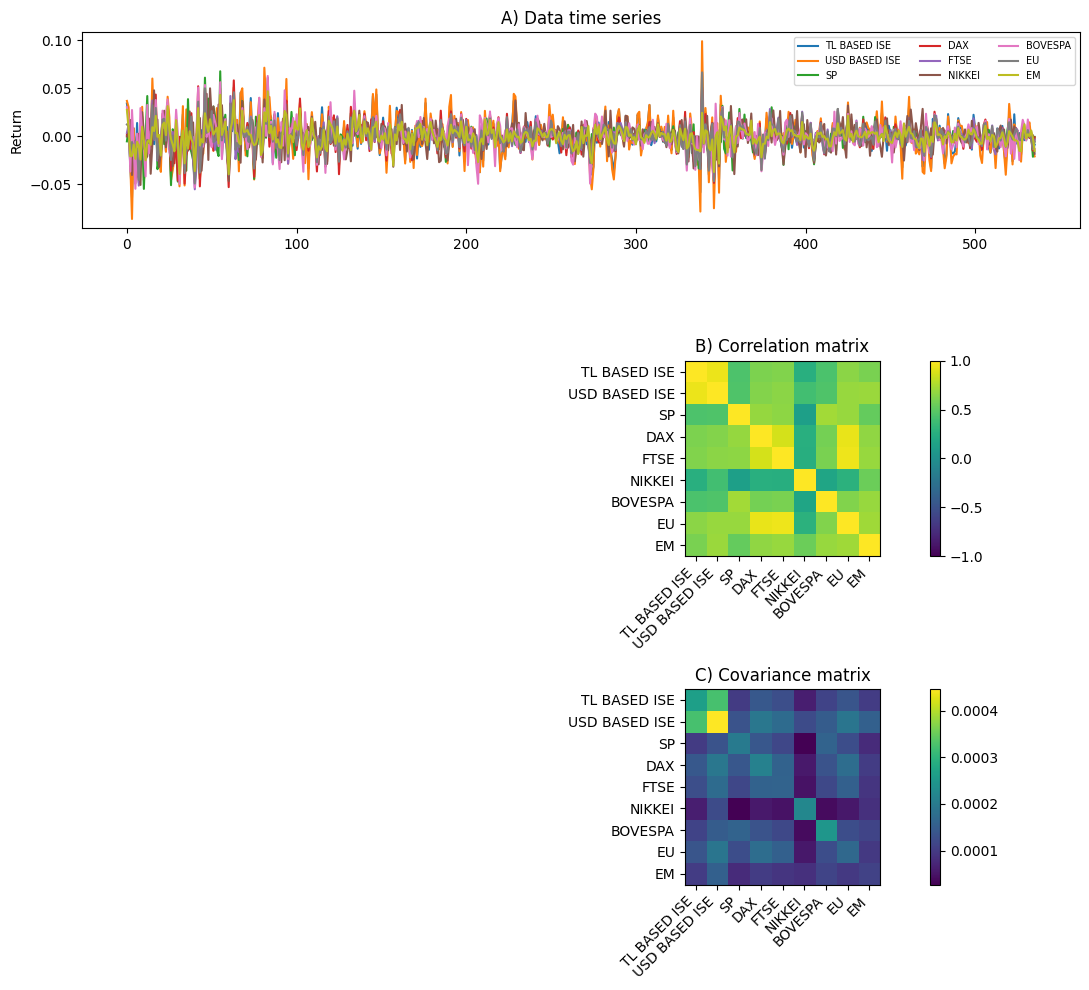

In [3]:
# Inspeksi data: time series, correlation matrix, dan covariance matrix
corrMat = np.corrcoef(Xc, rowvar=False)
covMat = (Xc.T @ Xc) / (Xc.shape[0] - 1)

fig, axs = plt.subplots(3, 1, figsize=(11, 10))

axs[0].plot(Xc)
axs[0].set_title('A) Data time series')
axs[0].set_ylabel('Return')
axs[0].legend(feature_names, fontsize=7, ncol=3)

im1 = axs[1].imshow(corrMat, vmin=-1, vmax=1)
axs[1].set_title('B) Correlation matrix')
axs[1].set_xticks(range(len(feature_names)))
axs[1].set_yticks(range(len(feature_names)))
axs[1].set_xticklabels(feature_names, rotation=45, ha='right')
axs[1].set_yticklabels(feature_names)
plt.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(covMat)
axs[2].set_title('C) Covariance matrix')
axs[2].set_xticks(range(len(feature_names)))
axs[2].set_yticks(range(len(feature_names)))
axs[2].set_xticklabels(feature_names, rotation=45, ha='right')
axs[2].set_yticklabels(feature_names)
plt.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()

In [4]:
# PCA manual menggunakan eigendecomposition covariance matrix
covMat = (Xc.T @ Xc) / (Xc.shape[0] - 1)
evals, evecs = np.linalg.eig(covMat)

sort_idx = np.argsort(evals)[::-1]
evals = np.real(evals[sort_idx])
evecs = np.real(evecs[:, sort_idx])

component_scores = Xc @ evecs
variance_explained = 100 * evals / np.sum(evals)

print('Variance of first two components:')
print(np.var(component_scores[:, :2], axis=0, ddof=1))
print('\nFirst two eigenvalues:')
print(evals[:2])
print('\nCorrelation PC 1 dan PC 2:')
print(np.corrcoef(component_scores[:, 0], component_scores[:, 1])[0, 1])

Variance of first two components:
[0.0013  0.00029]

First two eigenvalues:
[0.0013  0.00029]

Correlation PC 1 dan PC 2:
-1.701703099039016e-16


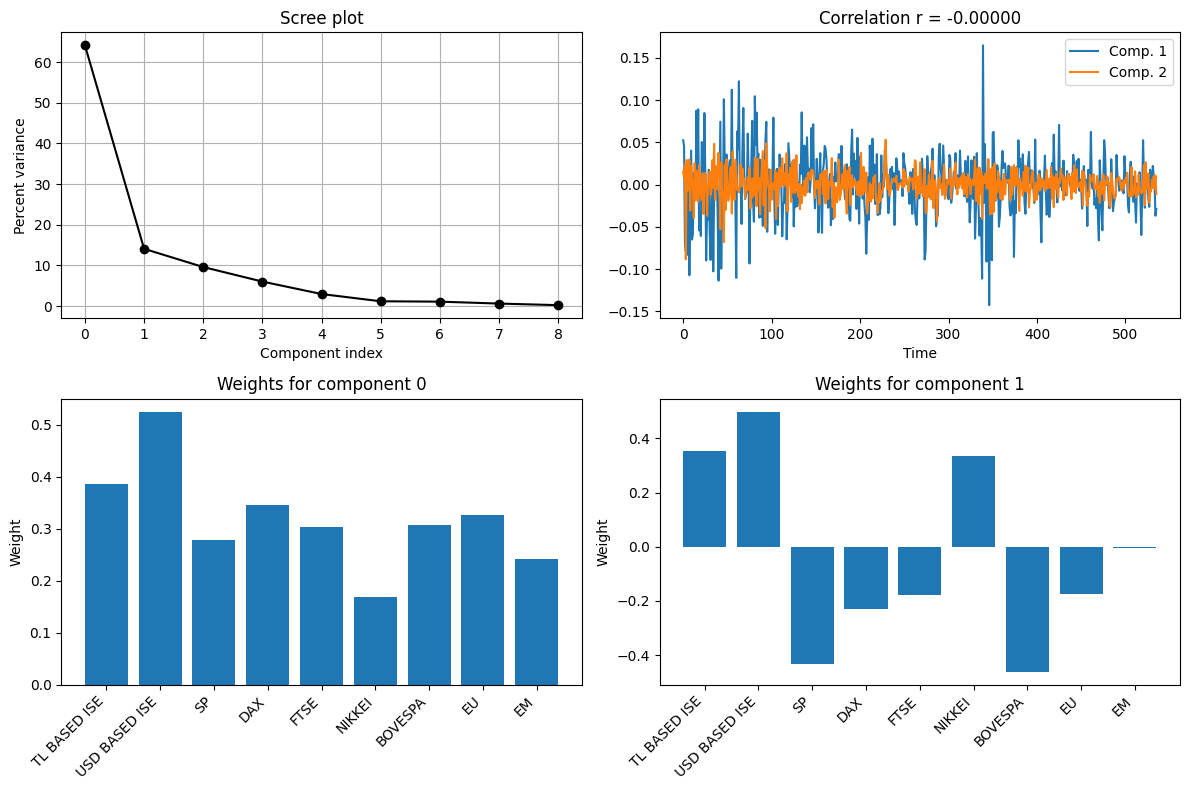

In [5]:
# Visualisasi hasil PCA seperti Figure 15-4
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].plot(variance_explained, 'ko-')
axs[0, 0].set_title('Scree plot')
axs[0, 0].set_xlabel('Component index')
axs[0, 0].set_ylabel('Percent variance')
axs[0, 0].grid(True)

axs[0, 1].plot(component_scores[:, 0], label='Comp. 1')
axs[0, 1].plot(component_scores[:, 1], label='Comp. 2')
axs[0, 1].set_title(f'Correlation r = {np.corrcoef(component_scores[:,0], component_scores[:,1])[0,1]:.5f}')
axs[0, 1].set_xlabel('Time')
axs[0, 1].legend()

axs[1, 0].bar(range(len(feature_names)), evecs[:, 0])
axs[1, 0].set_title('Weights for component 0')
axs[1, 0].set_ylabel('Weight')
axs[1, 0].set_xticks(range(len(feature_names)))
axs[1, 0].set_xticklabels(feature_names, rotation=45, ha='right')

axs[1, 1].bar(range(len(feature_names)), evecs[:, 1])
axs[1, 1].set_title('Weights for component 1')
axs[1, 1].set_ylabel('Weight')
axs[1, 1].set_xticks(range(len(feature_names)))
axs[1, 1].set_xticklabels(feature_names, rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Exercise 15-2 — PCA dengan SVD covariance matrix dan SVD data matrix

PCA dapat direproduksi dengan dua cara berbasis SVD:

1. SVD pada covariance matrix.
2. SVD langsung pada data matrix yang sudah mean-centered.

Eigenvalue dari covariance matrix setara dengan singular value data matrix yang dikuadratkan dan dibagi faktor normalisasi.

In [6]:
# SVD pada covariance matrix
Uc, sc, Vtc = np.linalg.svd(covMat)

# SVD pada data matrix langsung
Ux, sx, Vtx = np.linalg.svd(Xc, full_matrices=False)
evals_from_data_svd = (sx**2) / (Xc.shape[0] - 1)

print('Eigenvalues dari eig covariance:')
print(evals[:5])
print('\nSingular values dari SVD covariance:')
print(sc[:5])
print('\nEigenvalues dari SVD data matrix:')
print(evals_from_data_svd[:5])

print('\nSelisih eig covariance vs SVD covariance:')
print(np.linalg.norm(evals - sc))
print('\nSelisih eig covariance vs SVD data matrix:')
print(np.linalg.norm(evals - evals_from_data_svd))

Eigenvalues dari eig covariance:
[0.0013  0.00029 0.0002  0.00012 0.00006]

Singular values dari SVD covariance:
[0.0013  0.00029 0.0002  0.00012 0.00006]

Eigenvalues dari SVD data matrix:
[0.0013  0.00029 0.0002  0.00012 0.00006]

Selisih eig covariance vs SVD covariance:
1.1473742097255427e-18

Selisih eig covariance vs SVD data matrix:
2.2128060947324484e-18


## Exercise 15-3 — PCA manual dibandingkan dengan PCA sklearn

Exercise ini membandingkan PCA manual dengan implementasi `PCA` dari `sklearn.decomposition`.

In [7]:
from sklearn.decomposition import PCA

pca = PCA()
sk_scores = pca.fit_transform(Xc)

print('Eigenvalues PCA manual:')
print(evals[:5])
print('\nExplained variance sklearn PCA:')
print(pca.explained_variance_[:5])
print('\nPercent variance manual:')
print(variance_explained[:5])
print('\nPercent variance sklearn:')
print(100 * pca.explained_variance_ratio_[:5])

Eigenvalues PCA manual:
[0.0013  0.00029 0.0002  0.00012 0.00006]

Explained variance sklearn PCA:
[0.0013  0.00029 0.0002  0.00012 0.00006]

Percent variance manual:
[64.1014  14.08853  9.61238  6.03926  2.97963]

Percent variance sklearn:
[64.1014  14.08853  9.61238  6.03926  2.97963]


## Exercise 15-4 — PCA pada simulated data

Exercise ini membuat dua stream data, memutar keduanya dengan rotation matrix, lalu menggunakan SVD untuk melakukan PCA. Hasilnya menunjukkan bahwa PCA memaksimalkan arah variance, tetapi basis orthogonal PCA belum tentu menjadi basis terbaik untuk menangkap struktur data yang terlihat secara visual.

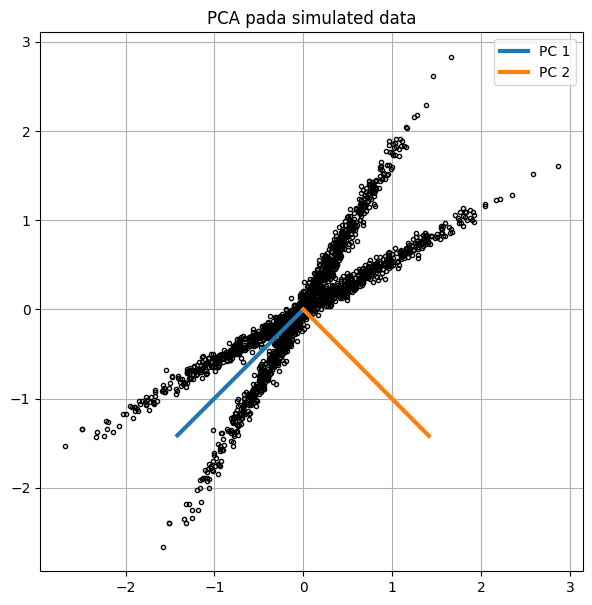

In [8]:
np.random.seed(1)

N = 1000
base_data = np.random.randn(N, 2)
base_data[:, 1] *= 0.05

def rotation_matrix(theta):
  return np.array([
    [np.cos(theta), np.sin(theta)],
    [-np.sin(theta), np.cos(theta)]
  ])

R1 = rotation_matrix(-np.pi / 6)
R2 = rotation_matrix(-np.pi / 3)

stream1 = base_data @ R1.T
stream2 = base_data @ R2.T
sim_data = np.vstack((stream1, stream2))
sim_data -= np.mean(sim_data, axis=0, keepdims=True)

U_sim, s_sim, Vt_sim = np.linalg.svd(sim_data, full_matrices=False)
V_sim = Vt_sim.T

plt.figure(figsize=(7, 7))
plt.plot(sim_data[:, 0], sim_data[:, 1], 'ko', markerfacecolor='none', markersize=3)
for i in range(2):
  vec = V_sim[:, i] * 2
  plt.plot([0, vec[0]], [0, vec[1]], linewidth=3, label=f'PC {i+1}')
plt.axis('equal')
plt.grid(True)
plt.title('PCA pada simulated data')
plt.legend()
plt.show()

## Linear Discriminant Analysis

LDA mencari arah dalam data space yang memisahkan kategori data secara maksimal. Berbeda dengan PCA yang memaksimalkan variance, LDA memaksimalkan rasio antara between-class covariance dan within-class covariance.

Solusi LDA diperoleh melalui generalized eigendecomposition terhadap dua covariance matrix.

## Exercise 15-5 — Membuat simulated data untuk LDA

Exercise ini membuat dua kelas data 2D yang masing-masing berisi 200 sample. Dimensi kedua ditambahkan ke dimensi pertama untuk memberi korelasi antar fitur. Kelas pertama diberi offset `[2, -1]`.

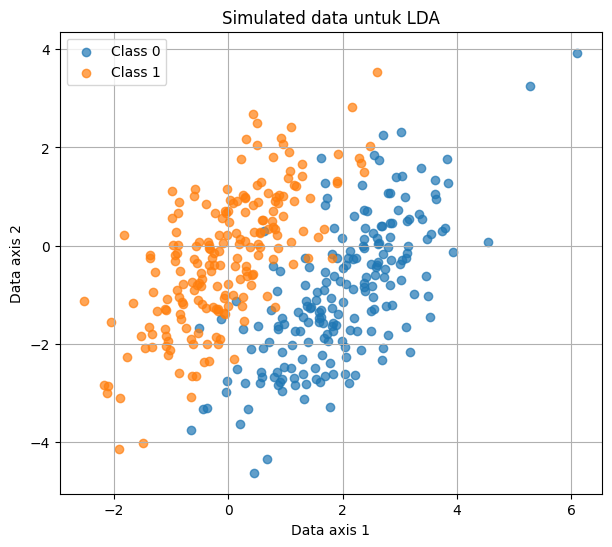

In [9]:
np.random.seed(2)

N = 200
class0 = np.random.randn(N, 2)
class1 = np.random.randn(N, 2)

class0[:, 1] += class0[:, 0]
class1[:, 1] += class1[:, 0]
class0 += np.array([2, -1])

X_lda = np.vstack((class0, class1))
y_lda = np.hstack((np.zeros(N), np.ones(N))).astype(int)

plt.figure(figsize=(7, 6))
plt.scatter(X_lda[y_lda == 0, 0], X_lda[y_lda == 0, 1], label='Class 0', alpha=.7)
plt.scatter(X_lda[y_lda == 1, 0], X_lda[y_lda == 1, 1], label='Class 1', alpha=.7)
plt.xlabel('Data axis 1')
plt.ylabel('Data axis 2')
plt.title('Simulated data untuk LDA')
plt.grid(True)
plt.legend()
plt.show()

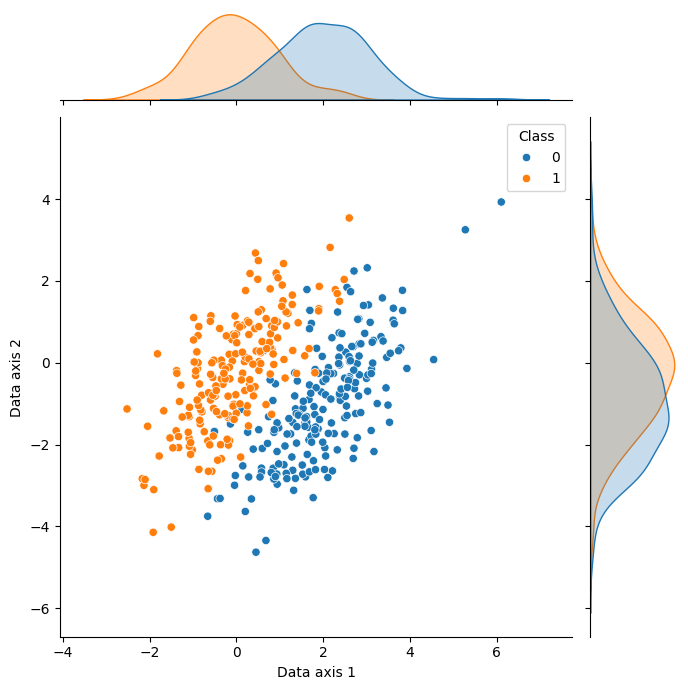

In [10]:
# Reproduce graph A menggunakan seaborn jointplot
import seaborn as sns

lda_df = pd.DataFrame({
  'Data axis 1': X_lda[:, 0],
  'Data axis 2': X_lda[:, 1],
  'Class': y_lda.astype(str)
})

sns.jointplot(data=lda_df, x='Data axis 1', y='Data axis 2', hue='Class', height=7)
plt.show()

## Exercise 15-6 — Manual LDA dengan generalized eigendecomposition

Within-class covariance dibuat dari rata-rata covariance tiap kelas. Between-class covariance dibuat dari covariance matrix terhadap mean fitur tiap kelas. Data diproyeksikan ke LDA space dengan `X @ V`.

In [11]:
# Mean-center data per fitur
Xc_lda = X_lda - np.mean(X_lda, axis=0, keepdims=True)

# Within-class covariance
cov0 = np.cov(Xc_lda[y_lda == 0, :].T)
cov1 = np.cov(Xc_lda[y_lda == 1, :].T)
CW = (cov0 + cov1) / 2

# Between-class covariance
class_means = np.vstack((
  np.mean(Xc_lda[y_lda == 0, :], axis=0),
  np.mean(Xc_lda[y_lda == 1, :], axis=0)
))
CB = np.cov(class_means.T)

# Generalized eigendecomposition
lda_evals, lda_evecs = eigh(CB, CW)
idx = np.argsort(lda_evals)[::-1]
lda_evals = lda_evals[idx]
lda_evecs = lda_evecs[:, idx]

lda_scores = Xc_lda @ lda_evecs

# Atur tanda agar class 0 cenderung negatif dan class 1 cenderung positif pada komponen pertama
if lda_scores[y_lda == 0, 0].mean() > lda_scores[y_lda == 1, 0].mean():
  lda_evecs[:, 0] *= -1
  lda_scores = Xc_lda @ lda_evecs

pred_manual = (lda_scores[:, 0] > 0).astype(int)
if np.mean(pred_manual == y_lda) < .5:
  pred_manual = 1 - pred_manual

acc_manual = np.mean(pred_manual == y_lda) * 100
print(f'Accuracy = {acc_manual:.2f}%')

Accuracy = 95.25%


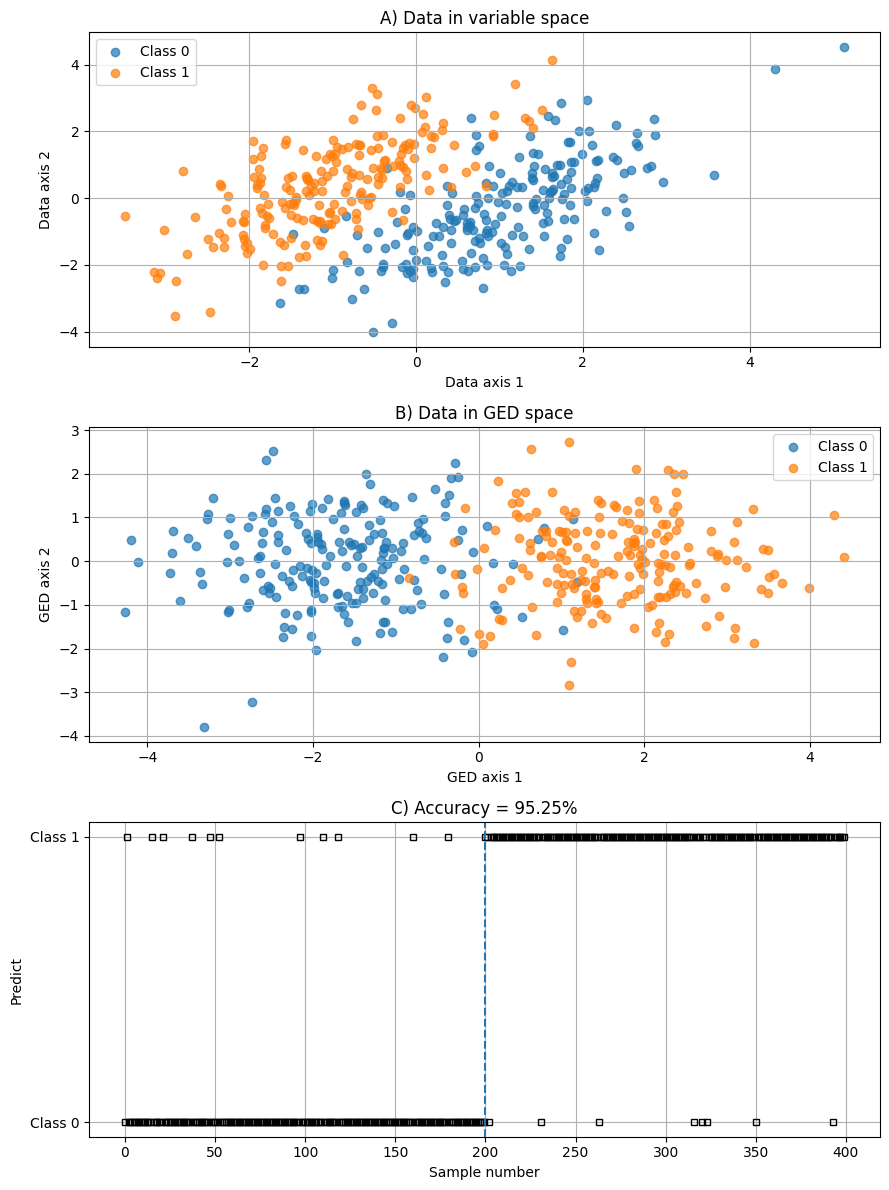

In [12]:
fig, axs = plt.subplots(3, 1, figsize=(9, 12))

axs[0].scatter(Xc_lda[y_lda == 0, 0], Xc_lda[y_lda == 0, 1], label='Class 0', alpha=.7)
axs[0].scatter(Xc_lda[y_lda == 1, 0], Xc_lda[y_lda == 1, 1], label='Class 1', alpha=.7)
axs[0].set_title('A) Data in variable space')
axs[0].set_xlabel('Data axis 1')
axs[0].set_ylabel('Data axis 2')
axs[0].grid(True)
axs[0].legend()

axs[1].scatter(lda_scores[y_lda == 0, 0], lda_scores[y_lda == 0, 1], label='Class 0', alpha=.7)
axs[1].scatter(lda_scores[y_lda == 1, 0], lda_scores[y_lda == 1, 1], label='Class 1', alpha=.7)
axs[1].set_title('B) Data in GED space')
axs[1].set_xlabel('GED axis 1')
axs[1].set_ylabel('GED axis 2')
axs[1].grid(True)
axs[1].legend()

axs[2].plot(pred_manual, 'ks', markerfacecolor='none', markersize=4)
axs[2].axvline(N, linestyle='--')
axs[2].set_yticks([0, 1])
axs[2].set_yticklabels(['Class 0', 'Class 1'])
axs[2].set_xlabel('Sample number')
axs[2].set_ylabel('Predict')
axs[2].set_title(f'C) Accuracy = {acc_manual:.2f}%')
axs[2].grid(True)

plt.tight_layout()
plt.show()

## Exercise 15-7 — Orthogonality pada generalized eigendecomposition

Pada generalized eigendecomposition, eigenvector matrix `V` tidak harus orthogonal dalam bentuk `V.T @ V`, tetapi orthogonal dalam ruang denominator matrix, yaitu `V.T @ CW @ V`.

In [13]:
print('V.T @ V:')
print(lda_evecs.T @ lda_evecs)

print('\nV.T @ CW @ V:')
print(lda_evecs.T @ CW @ lda_evecs)

V.T @ V:
[[ 2.43518 -0.19322]
 [-0.19322  0.40573]]

V.T @ CW @ V:
[[ 1. -0.]
 [-0.  1.]]


## Exercise 15-8 — LDA menggunakan sklearn

Exercise ini mereproduksi hasil LDA menggunakan `LinearDiscriminantAnalysis` dari `sklearn.discriminant_analysis`, lalu membandingkan prediksi sklearn dengan prediksi manual.

Accuracy manual : 95.25%
Accuracy sklearn: 95.25%
Prediksi sama: True


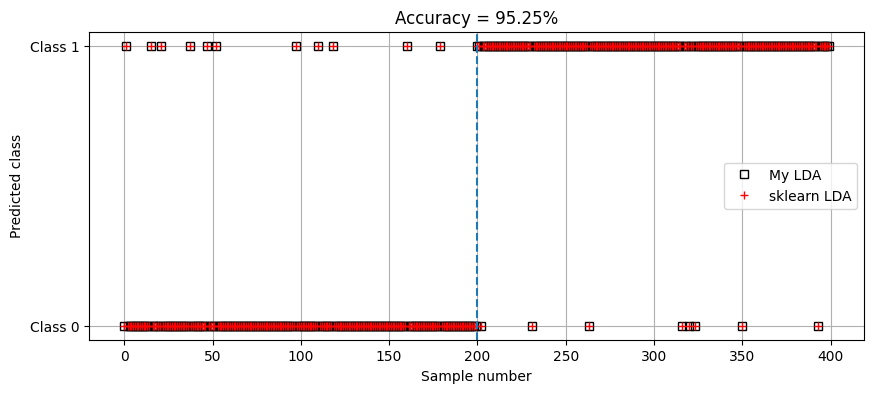

In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis(solver='eigen')
lda_model.fit(X_lda, y_lda)
pred_sklearn = lda_model.predict(X_lda)
acc_sklearn = np.mean(pred_sklearn == y_lda) * 100

print(f'Accuracy manual : {acc_manual:.2f}%')
print(f'Accuracy sklearn: {acc_sklearn:.2f}%')
print('Prediksi sama:', np.all(pred_manual == pred_sklearn))

plt.figure(figsize=(10, 4))
plt.plot(pred_manual, 'ks', markerfacecolor='none', label='My LDA')
plt.plot(pred_sklearn, 'r+', label='sklearn LDA')
plt.axvline(N, linestyle='--')
plt.yticks([0, 1], ['Class 0', 'Class 1'])
plt.xlabel('Sample number')
plt.ylabel('Predicted class')
plt.title(f'Accuracy = {acc_sklearn:.2f}%')
plt.legend()
plt.grid(True)
plt.show()

## Exercise 15-9 — Shrinkage regularization pada LDA

Exercise ini menggunakan train/test split. Setiap shrinkage amount diuji dengan 50 random split, train sebanyak 350 sample dan test sebanyak 50 sample.

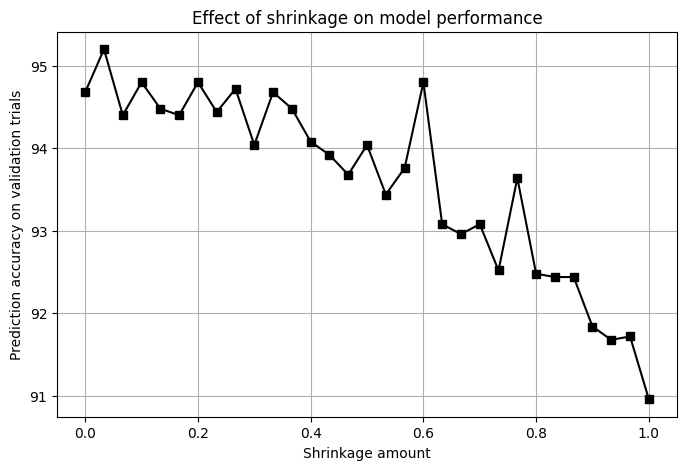

In [15]:
np.random.seed(3)

shrinkages = np.linspace(0, 1, 31)
accs = np.zeros(len(shrinkages))
iterations = 50

for si, shrink in enumerate(shrinkages):
  tmp_acc = []

  for _ in range(iterations):
    perm_idx = np.random.permutation(len(y_lda))
    train_idx = perm_idx[:350]
    test_idx = perm_idx[350:]

    shrink_arg = None if shrink == 0 else float(shrink)
    model = LinearDiscriminantAnalysis(solver='eigen', shrinkage=shrink_arg)
    model.fit(X_lda[train_idx], y_lda[train_idx])
    pred = model.predict(X_lda[test_idx])
    tmp_acc.append(np.mean(pred == y_lda[test_idx]) * 100)

  accs[si] = np.mean(tmp_acc)

plt.figure(figsize=(8, 5))
plt.plot(shrinkages, accs, 'ks-')
plt.xlabel('Shrinkage amount')
plt.ylabel('Prediction accuracy on validation trials')
plt.title('Effect of shrinkage on model performance')
plt.grid(True)
plt.show()

## Low-Rank Approximation via SVD

Low-rank approximation dilakukan dengan mengambil sebagian singular vectors dan singular values. Dengan menyimpan hanya komponen penting, ukuran data dapat dikurangi, tetapi kualitas rekonstruksi bergantung pada jumlah komponen yang dipakai.

## Exercise 15-10 — SVD low-rank approximation pada gambar Stravinsky

Exercise ini memakai gambar Stravinsky dari Wikipedia. Jika file gambar belum ada di Colab, upload gambar tersebut dan beri nama `stravinsky.jpg` atau upload saat cell meminta file.

In [16]:
def load_stravinsky_image(path='stravinsky.jpg'):
  if not os.path.exists(path):
    try:
      from google.colab import files
      print('Upload gambar Stravinsky dari Wikipedia.')
      uploaded = files.upload()
      path = next(iter(uploaded.keys()))
    except Exception as e:
      raise FileNotFoundError('Gambar Stravinsky belum tersedia.') from e

  img = Image.open(path).convert('L')
  img = np.asarray(img, dtype=float)
  img = (img - np.min(img)) / (np.max(img) - np.min(img))
  return img


def svd_rank1_layers(img, max_layers=4):
  U, s, Vt = np.linalg.svd(img, full_matrices=False)
  layers = []
  cumulative = []
  running = np.zeros_like(img)

  for i in range(max_layers):
    layer = s[i] * np.outer(U[:, i], Vt[i, :])
    running = running + layer
    layers.append(layer)
    cumulative.append(running.copy())

  return U, s, Vt, layers, cumulative

stravinsky = load_stravinsky_image()
U_img, s_img, Vt_img, layers_img, cumulative_img = svd_rank1_layers(stravinsky, 4)

print('Matrix size:', stravinsky.shape)
print('Rank:', np.linalg.matrix_rank(stravinsky))

Upload gambar Stravinsky dari Wikipedia.


Saving images.jpeg to images.jpeg
Matrix size: (655, 468)
Rank: 468


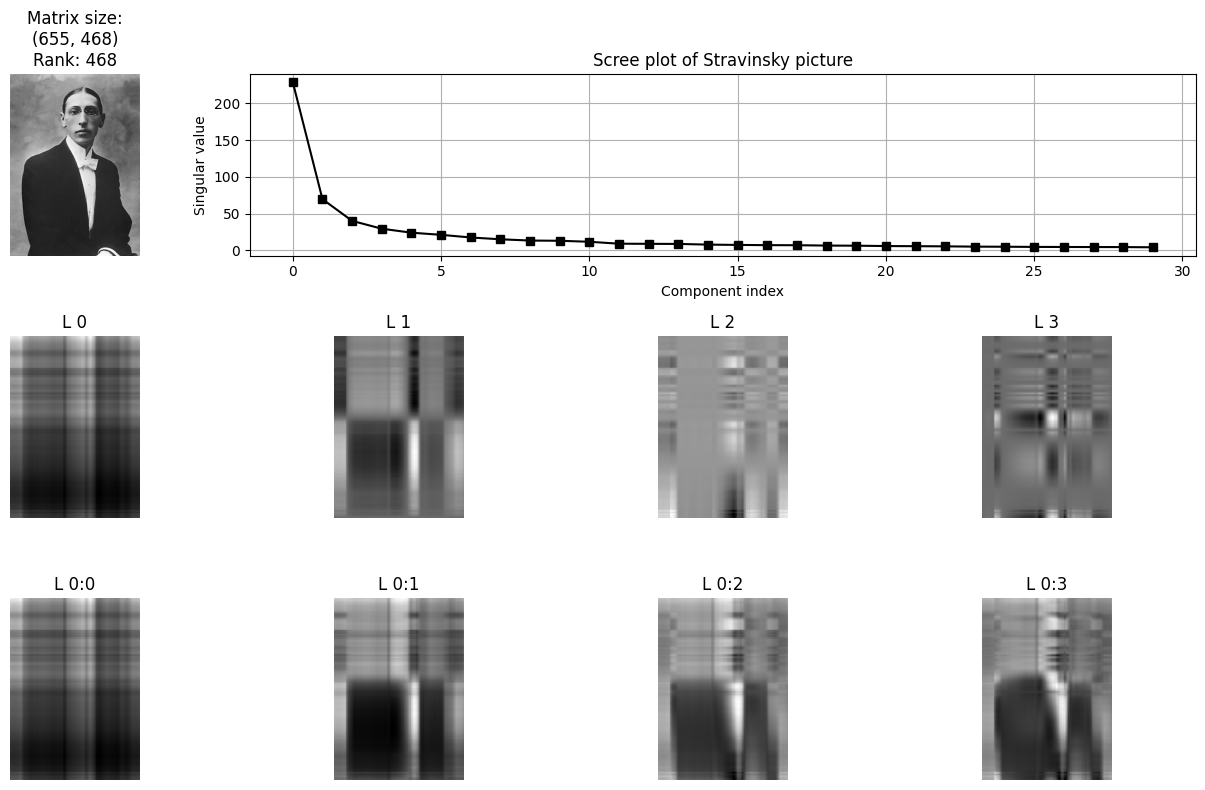

In [17]:
fig = plt.figure(figsize=(13, 8))

ax = plt.subplot2grid((3, 4), (0, 0))
ax.imshow(stravinsky, cmap='gray')
ax.set_title(f'Matrix size:\n{stravinsky.shape}\nRank: {np.linalg.matrix_rank(stravinsky)}')
ax.axis('off')

ax = plt.subplot2grid((3, 4), (0, 1), colspan=3)
ax.plot(s_img[:30], 'ks-')
ax.set_title('Scree plot of Stravinsky picture')
ax.set_xlabel('Component index')
ax.set_ylabel('Singular value')
ax.grid(True)

for i in range(4):
  ax = plt.subplot2grid((3, 4), (1, i))
  ax.imshow(layers_img[i], cmap='gray')
  ax.set_title(f'L {i}')
  ax.axis('off')

for i in range(4):
  ax = plt.subplot2grid((3, 4), (2, i))
  ax.imshow(cumulative_img[i], cmap='gray')
  ax.set_title(f'L 0:{i}')
  ax.axis('off')

plt.tight_layout()
plt.show()

## Exercise 15-11 — Rekonstruksi gambar dengan lebih banyak layer

Exercise ini merekonstruksi gambar memakai `k = 80` komponen, menampilkan original image, reconstructed image, dan squared error. Lalu dihitung ukuran data original, ukuran rekonstruksi penuh, ukuran vector rekonstruksi, dan compression ratio.

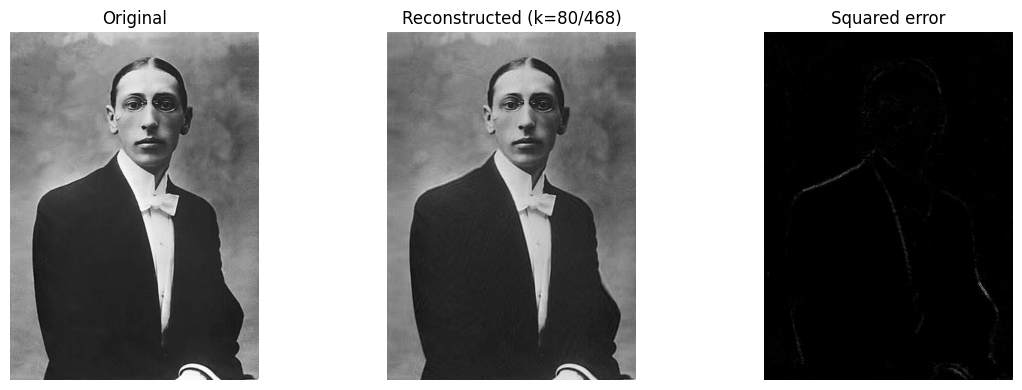

Original is 2.34 mb
Reconstruction is 2.34 mb
Recon vectors are 0.69 mb (using k=80 comps.)
Compression of 29.33%


In [18]:
k = 80
recon80 = U_img[:, :k] @ np.diag(s_img[:k]) @ Vt_img[:k, :]
squared_error = (stravinsky - recon80) ** 2

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(stravinsky, cmap='gray')
axs[0].set_title('Original')
axs[0].axis('off')

axs[1].imshow(recon80, cmap='gray')
axs[1].set_title(f'Reconstructed (k={k}/{len(s_img)})')
axs[1].axis('off')

axs[2].imshow(squared_error, cmap='gray')
axs[2].set_title('Squared error')
axs[2].axis('off')

plt.tight_layout()
plt.show()

original_mb = stravinsky.nbytes / (1024**2)
reconstruction_mb = recon80.nbytes / (1024**2)
recon_vectors_bytes = U_img[:, :k].nbytes + s_img[:k].nbytes + Vt_img[:k, :].nbytes
recon_vectors_mb = recon_vectors_bytes / (1024**2)
compression_percent = 100 * recon_vectors_bytes / stravinsky.nbytes

print(f'Original is {original_mb:.2f} mb')
print(f'Reconstruction is {reconstruction_mb:.2f} mb')
print(f'Recon vectors are {recon_vectors_mb:.2f} mb (using k={k} comps.)')
print(f'Compression of {compression_percent:.2f}%')

## Exercise 15-12 — Error rekonstruksi sebagai fungsi rank

Exercise ini menghitung Frobenius distance antara original image dan rekonstruksi rank-k untuk semua nilai `k`.

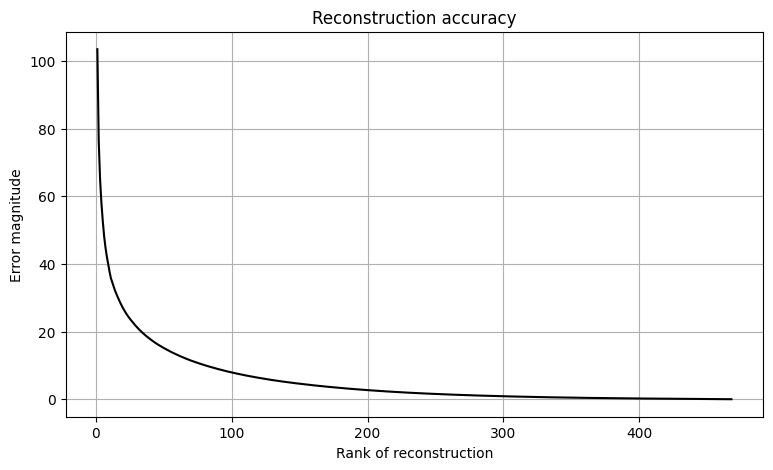

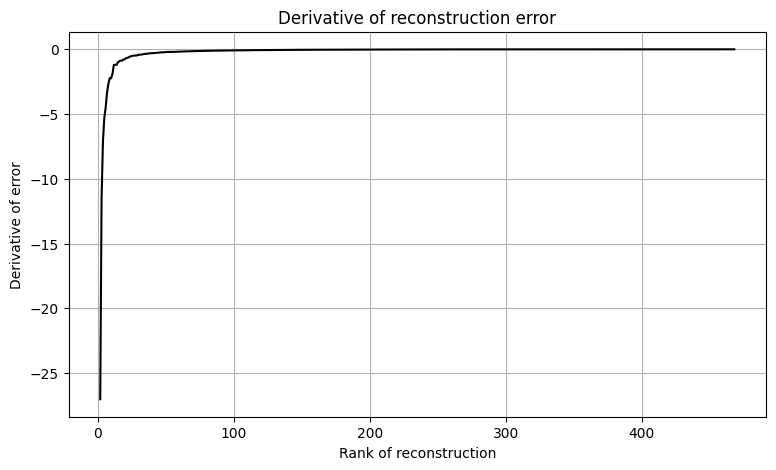

Error pada full SVD reconstruction: 7.872908833498856e-13


In [19]:
running_recon = np.zeros_like(stravinsky)
recon_errors = np.zeros(len(s_img))

for i in range(len(s_img)):
  running_recon += s_img[i] * np.outer(U_img[:, i], Vt_img[i, :])
  recon_errors[i] = np.linalg.norm(stravinsky - running_recon, 'fro')

error_derivative = np.diff(recon_errors)

plt.figure(figsize=(9, 5))
plt.plot(np.arange(1, len(s_img)+1), recon_errors, 'k')
plt.xlabel('Rank of reconstruction')
plt.ylabel('Error magnitude')
plt.title('Reconstruction accuracy')
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(np.arange(2, len(s_img)+1), error_derivative, 'k')
plt.xlabel('Rank of reconstruction')
plt.ylabel('Derivative of error')
plt.title('Derivative of reconstruction error')
plt.grid(True)
plt.show()

full_recon_error = recon_errors[-1]
print('Error pada full SVD reconstruction:', full_recon_error)

## SVD for Image Denoising

Denoising via SVD adalah bentuk low-rank approximation. Komponen SVD yang dianggap noise dapat dihilangkan, lalu gambar direkonstruksi tanpa komponen tersebut.

## Exercise 15-13 — Menambahkan sine grating noise dan inspeksi SVD

Noise dibuat sebagai 2D sine grating:

\[
Z = \sin(2\pi f(X\cos	heta + Y\sin	heta))
\]

Parameter yang digunakan adalah `f = .02` dan `theta = pi/6`.

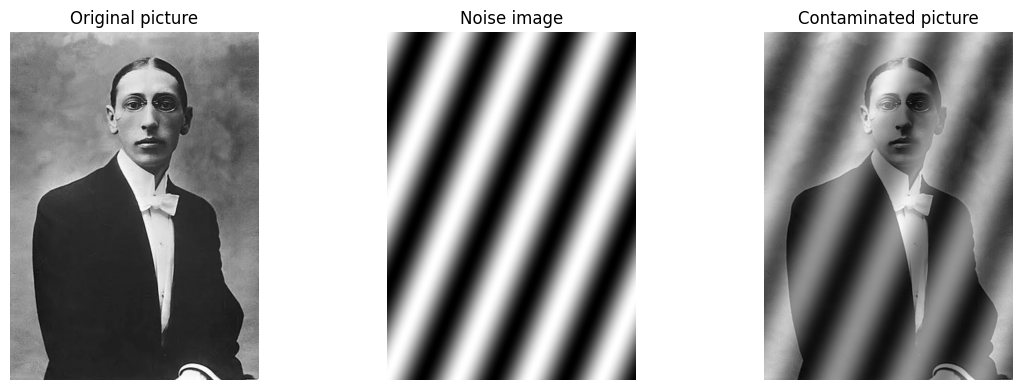

In [20]:
def minmax_scale(M):
  return (M - np.min(M)) / (np.max(M) - np.min(M))

rows, cols = stravinsky.shape
x = np.linspace(-100, 100, cols)
y = np.linspace(-100, 100, rows)
Xgrid, Ygrid = np.meshgrid(x, y)

freq = .02
theta = np.pi / 6
noise = np.sin(2 * np.pi * freq * (Xgrid * np.cos(theta) + Ygrid * np.sin(theta)))
noise = minmax_scale(noise)

noisy_stravinsky = minmax_scale(stravinsky + noise)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(stravinsky, cmap='gray')
axs[0].set_title('Original picture')
axs[0].axis('off')

axs[1].imshow(noise, cmap='gray')
axs[1].set_title('Noise image')
axs[1].axis('off')

axs[2].imshow(noisy_stravinsky, cmap='gray')
axs[2].set_title('Contaminated picture')
axs[2].axis('off')

plt.tight_layout()
plt.show()

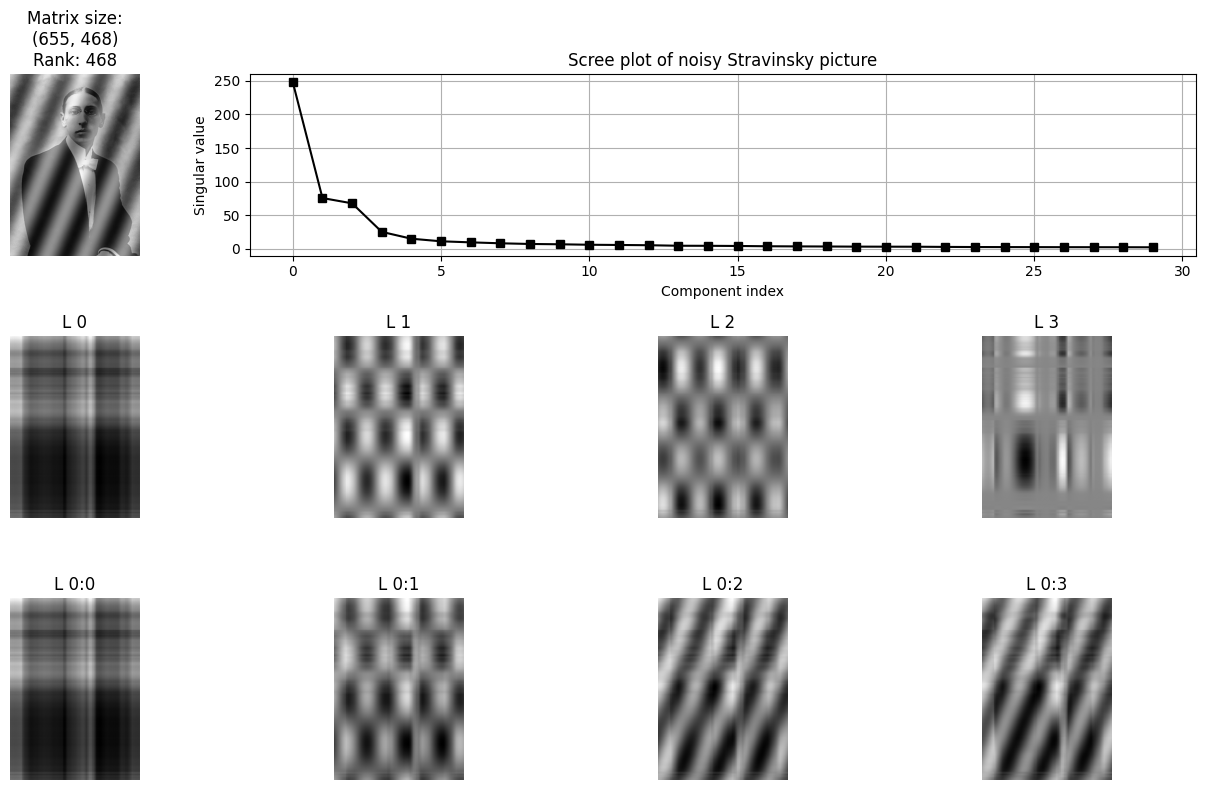

In [21]:
U_noisy, s_noisy, Vt_noisy, layers_noisy, cumulative_noisy = svd_rank1_layers(noisy_stravinsky, 4)

fig = plt.figure(figsize=(13, 8))

ax = plt.subplot2grid((3, 4), (0, 0))
ax.imshow(noisy_stravinsky, cmap='gray')
ax.set_title(f'Matrix size:\n{noisy_stravinsky.shape}\nRank: {np.linalg.matrix_rank(noisy_stravinsky)}')
ax.axis('off')

ax = plt.subplot2grid((3, 4), (0, 1), colspan=3)
ax.plot(s_noisy[:30], 'ks-')
ax.set_title('Scree plot of noisy Stravinsky picture')
ax.set_xlabel('Component index')
ax.set_ylabel('Singular value')
ax.grid(True)

for i in range(4):
  ax = plt.subplot2grid((3, 4), (1, i))
  ax.imshow(layers_noisy[i], cmap='gray')
  ax.set_title(f'L {i}')
  ax.axis('off')

for i in range(4):
  ax = plt.subplot2grid((3, 4), (2, i))
  ax.imshow(cumulative_noisy[i], cmap='gray')
  ax.set_title(f'L 0:{i}')
  ax.axis('off')

plt.tight_layout()
plt.show()

## Exercise 15-14 — Denoising dengan menghapus komponen noise

Noise tampak berada pada komponen kedua dan ketiga, sehingga rekonstruksi dibuat memakai semua komponen kecuali komponen indeks `1` dan `2`.

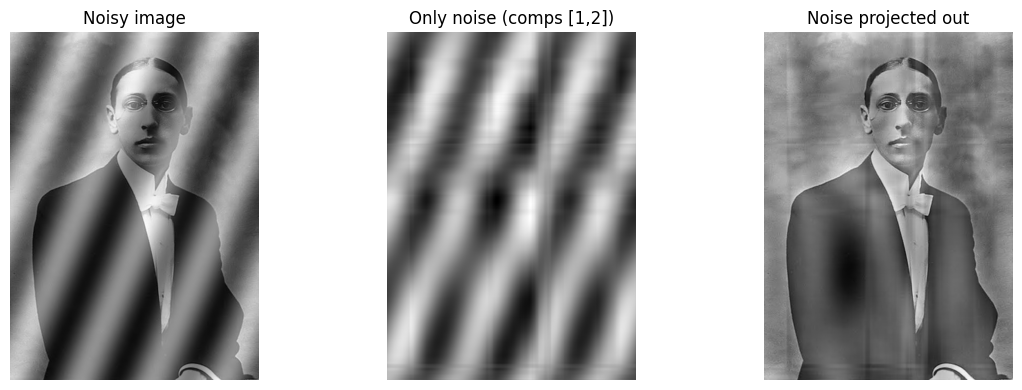

In [22]:
s_denoised = s_noisy.copy()
s_noise_only = np.zeros_like(s_noisy)

noise_components = [1, 2]
s_noise_only[noise_components] = s_noisy[noise_components]
s_denoised[noise_components] = 0

only_noise = U_noisy @ np.diag(s_noise_only) @ Vt_noisy
denoised_img = U_noisy @ np.diag(s_denoised) @ Vt_noisy

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(noisy_stravinsky, cmap='gray')
axs[0].set_title('Noisy image')
axs[0].axis('off')

axs[1].imshow(only_noise, cmap='gray')
axs[1].set_title('Only noise (comps [1,2])')
axs[1].axis('off')

axs[2].imshow(denoised_img, cmap='gray')
axs[2].set_title('Noise projected out')
axs[2].axis('off')

plt.tight_layout()
plt.show()

## Ringkasan Bab

- PCA mencari weighted combination dari fitur data yang memaksimalkan variance.
- PCA dapat dilakukan dengan eigendecomposition covariance matrix atau SVD.
- LDA mencari arah linear yang memaksimalkan pemisahan kelas.
- LDA dapat diselesaikan dengan generalized eigendecomposition pada covariance matrix between-class dan within-class.
- Low-rank approximation memakai sebagian komponen SVD untuk kompresi data.
- Denoising berbasis SVD dilakukan dengan menghapus komponen yang merepresentasikan noise atau artifact.